# Simulating a given network and a generator

Every chemistry in Chemart gets its reaction network in one of two ways
(`describe_chemistry(id)["network"]`):

- **given**: the chemistry *is* a reaction network. Chemart writes it down
  from the parameters, and simulating it means integrating its dynamics.
- **generated**: the network is the *output* of the chemistry's algorithm.
  Chemart runs that algorithm, and the network is the record of what happened.

This notebook simulates one of each: the Brusselator (given) and the
prime-number chemistry (generated).

In [1]:
import chemart
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

## 1. A given network: the Brusselator

Four reactions and six species. `A` and `B` are held constant (buffered),
`X` and `Y` are the dynamic species, and `D` and `E` collect waste.

In [2]:
print(chemart.describe_chemistry("brusselator")["network"])

net = chemart.generate_network("brusselator", seed=1)
print(net.to_text())
print("buffered:", net.extras["buffered"])
print("initial state:", net.initial_state)

given
A -> X  [mass-action k=1.0]
B + X -> Y + D  [mass-action k=1.0]
2 X + Y -> 3 X  [mass-action k=1.0]
X -> E  [mass-action k=1.0]
buffered: ['A', 'B']
initial state: {'A': 1.0, 'B': 3.0, 'X': 0.0, 'Y': 0.0, 'D': 0.0, 'E': 0.0}


The network record is everything an ODE solver needs. `net.matrices()` gives
the reactant and product stoichiometry, each reaction carries its mass-action
rate constant, and buffered species stay fixed. This function turns any
given network with mass-action rates into rate equations:

In [3]:
def rate_equations(net):
    ids, R, P = net.matrices()
    R, S = R.toarray(), (P - R).toarray()          # reactant orders and net stoichiometry
    k = np.array([r.rate["k"] for r in net.reactions])
    fixed = np.isin(ids, net.extras.get("buffered", []))

    def rhs(t, x):
        v = k * np.prod(x[:, None] ** R, axis=0)   # mass-action rate of every reaction
        dx = S @ v
        dx[fixed] = 0.0
        return dx

    x0 = np.array([net.initial_state.get(s, 0.0) for s in ids])
    return ids, rhs, x0

The Brusselator oscillates when `b > 1 + a²`. With `a = 1`, that means
`b > 2`: below it, `X` and `Y` settle to a fixed point; above it, they
circle a limit cycle.

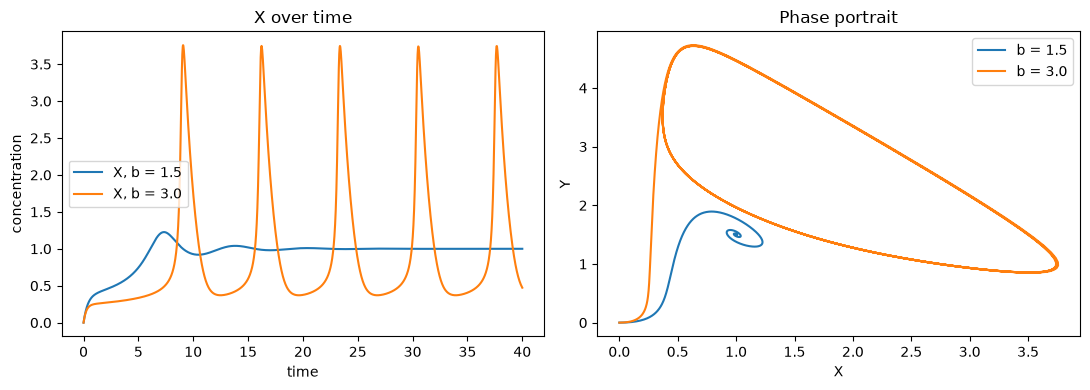

In [4]:
fig, (ax_t, ax_phase) = plt.subplots(1, 2, figsize=(11, 4))
for b in (1.5, 3.0):
    net = chemart.generate_network("brusselator", seed=1, b=b)
    ids, rhs, x0 = rate_equations(net)
    sol = solve_ivp(rhs, (0, 40), x0, method="LSODA", t_eval=np.linspace(0, 40, 2000))
    X, Y = sol.y[ids.index("X")], sol.y[ids.index("Y")]
    ax_t.plot(sol.t, X, label=f"X, b = {b}")
    ax_phase.plot(X, Y, label=f"b = {b}")

ax_t.set(xlabel="time", ylabel="concentration", title="X over time")
ax_phase.set(xlabel="X", ylabel="Y", title="Phase portrait")
ax_t.legend(); ax_phase.legend()
plt.tight_layout()

## 2. A generator: the prime-number chemistry

Here the molecules are integers. When a smaller number divides a larger one,
the larger is replaced by the quotient: `4 + 12 -> 4 + 3`. No network is
written down in advance: Chemart fills a well-stirred soup with random
numbers, lets them collide, and records every reaction that fired.

In [5]:
print(chemart.describe_chemistry("prime-number-chemistry")["network"])

net = chemart.generate_network("prime-number-chemistry", seed=1)
print(net.summary())

generated
prime-number-chemistry: 201 species, 159 reactions, status=observed
provides: catalysts, initial-state, stoichiometry, topology
seed: 1
extras: analysis, final_state, primes


The reactions are the ones that actually happened in this run, each with how
often it fired:

In [6]:
for r in sorted(net.reactions, key=lambda r: -(r.count or 0))[:8]:
    print(f"{r.count:3d} x  {r.to_text().split('  (x')[0]}")

  6 x  n9 + n3 -> 2 n3
  4 x  n4 + n2 -> 2 n2
  2 x  n26 + n2 -> n2 + n13
  2 x  n33 + n3 -> n3 + n11
  2 x  n3 + n6 -> n3 + n2
  2 x  n2 + n94 -> n2 + n47
  2 x  n7 + n49 -> 2 n7
  1 x  n261 + n29 -> n29 + n9


What the run shows is the chemistry's known result: composite numbers keep
being divided away, so the soup fills with primes. `extras["analysis"]`
tracks the fraction of primes after each generation (every 100 collisions).
Different seeds are different runs, and each generates its own network:

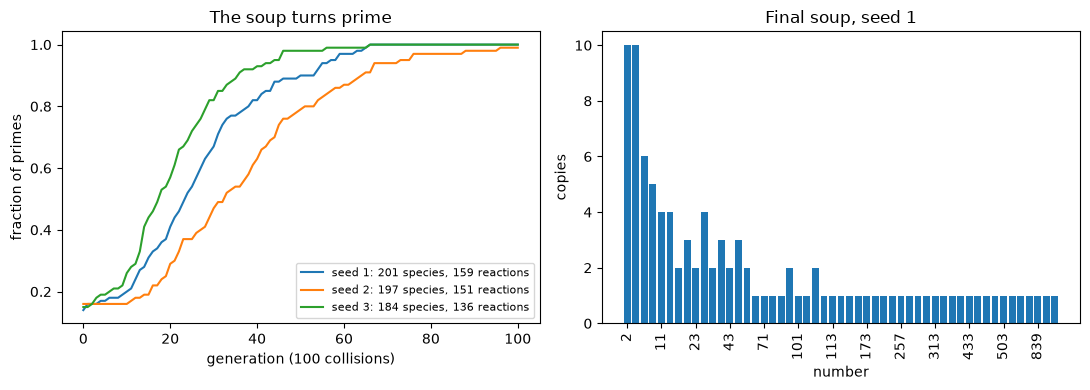

In [7]:
fig, (ax_frac, ax_pop) = plt.subplots(1, 2, figsize=(11, 4))
for seed in (1, 2, 3):
    run = chemart.generate_network("prime-number-chemistry", seed=seed)
    fraction = run.extras["analysis"]["prime_fraction"]
    ax_frac.plot(fraction, label=f"seed {seed}: {len(run.species)} species, {len(run.reactions)} reactions")

final = net.extras["final_state"]                  # seed 1: what the soup holds at the end
numbers = sorted((int(s[1:]), n) for s, n in final.items())
ax_pop.bar(range(len(numbers)), [n for _, n in numbers])
ax_pop.set_xticks(range(0, len(numbers), 4), [numbers[i][0] for i in range(0, len(numbers), 4)], rotation=90)

ax_frac.set(xlabel="generation (100 collisions)", ylabel="fraction of primes", title="The soup turns prime")
ax_pop.set(xlabel="number", ylabel="copies", title="Final soup, seed 1")
ax_frac.legend(fontsize=8)
plt.tight_layout()

In [8]:
remaining = [int(s[1:]) for s in net.extras["final_state"]]
composites = [n for n in remaining if any(n % d == 0 for d in range(2, int(n**0.5) + 1))]
print(f"{len(remaining)} distinct numbers left, {len(composites)} of them composite: {composites[:10]}")

51 distinct numbers left, 0 of them composite: []


## The difference in one line

- For a **given** network, Chemart hands you the network and you simulate its
  dynamics (here with `solve_ivp`). The network is the same every time.
- For a **generated** network, simulating *is* running the chemistry. The
  network comes out of the run (`status == "observed"`), with firing counts,
  and a different seed or starting soup generates a different one.

`chemart.list_chemistries()` lists every chemistry with its `network` value.